✅ Folder structure created!
📡 Downloading BTC data...


[*********************100%***********************]  1 of 1 completed


✅ BTC data saved!
📡 Downloading ETH data...


[*********************100%***********************]  1 of 1 completed


✅ ETH data saved!
📡 Downloading BNB data...


[*********************100%***********************]  1 of 1 completed


✅ BNB data saved!
📡 Downloading SOL data...


[*********************100%***********************]  1 of 1 completed


✅ SOL data saved!
✅ Phase 2 complete!
        Date          Close           High           Low           Open  \
0 2024-12-08  101236.015625  101399.992188  98771.515625   99921.914062   
1 2024-12-09   97432.718750  101272.507812  94355.914062  101237.062500   
2 2024-12-10   96675.429688   98270.156250  94321.257812   97441.234375   
3 2024-12-11  101173.031250  101913.359375  95747.226562   96656.062500   
4 2024-12-12  100043.000000  102524.914062  99339.953125  101167.804688   

         Volume    Return  Volatility_7d  Volatility_14d  Price_Mean_7d  \
0  4.412575e+10  0.013137       0.020993        0.024602   98329.947545   
1  1.106765e+11 -0.037569       0.025949        0.022689   98553.863839   
2  1.048238e+11 -0.007772       0.026250        0.022494   98650.044643   
3  8.539141e+10  0.046523       0.029938        0.022950   98993.544643   
4  7.207398e+10 -0.011169       0.028629        0.023239   99486.320312   

   Price_Mean_14d  Price_Momentum  Return_Lag_1  Return_Lag_

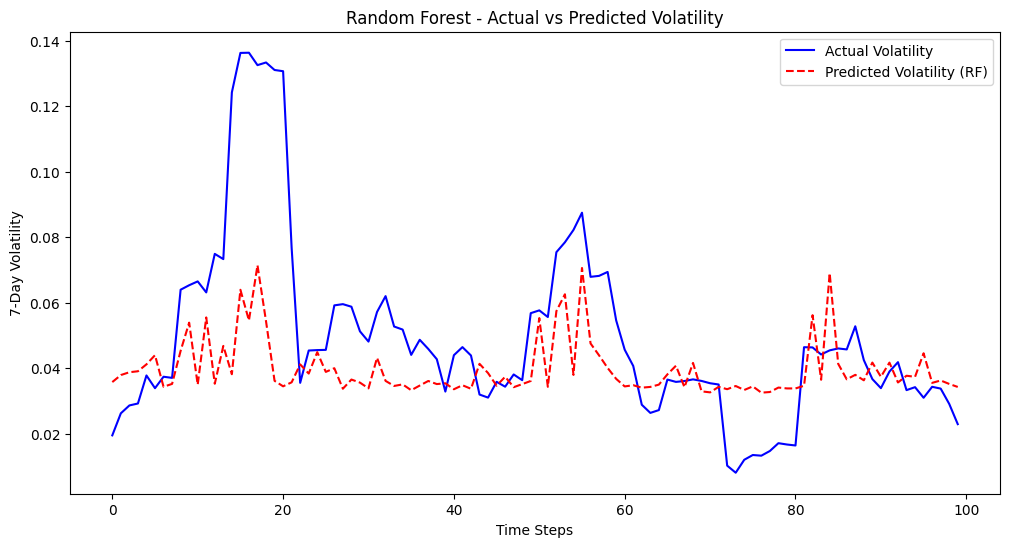

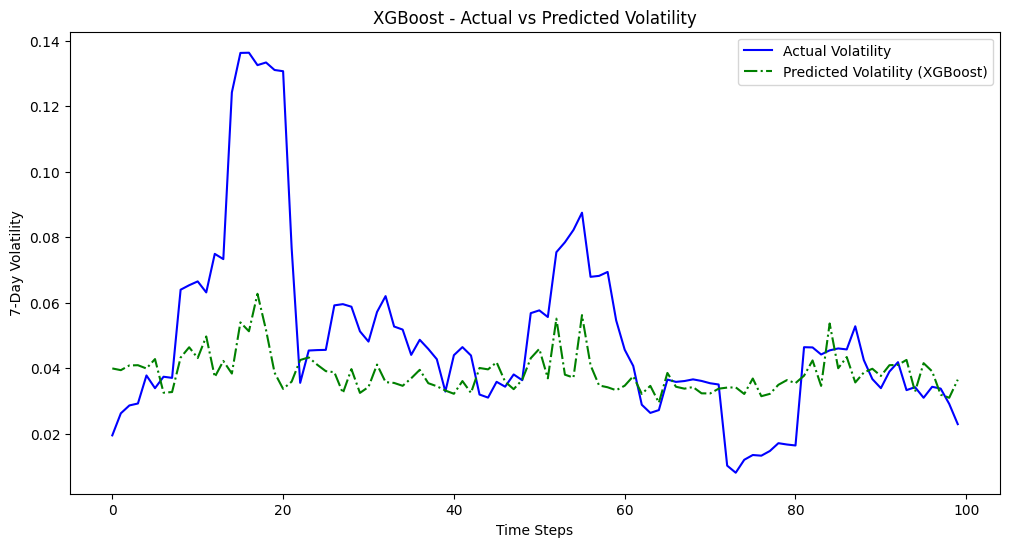

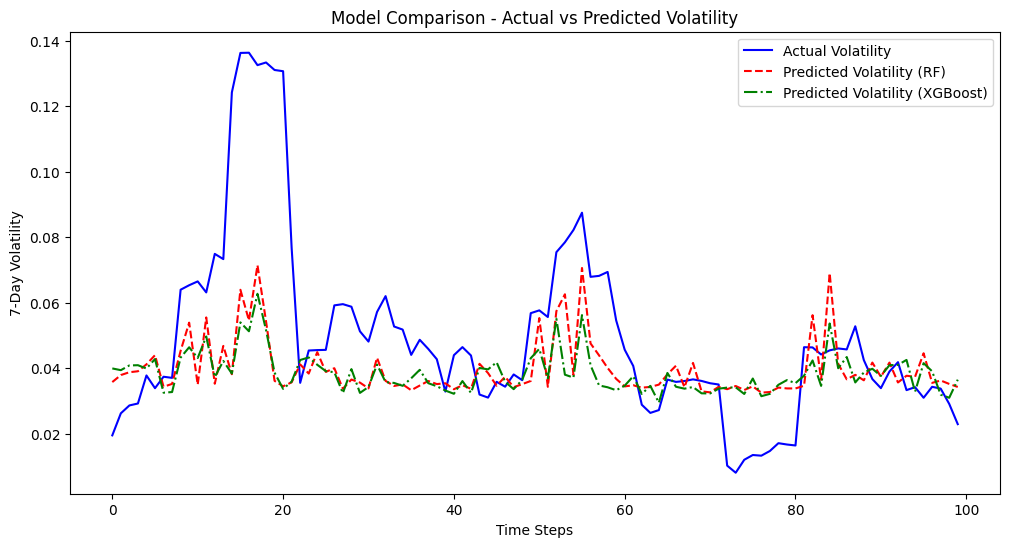

In [4]:
# ========================
# Phase 1: Import Libraries & Create Folders
# ========================
import os
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime

# Import for XGBoost
import xgboost as xgb 

# Folders for project
folders = ["data", "models", "app", "notebooks"]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Folder structure created!")
# ========================
# Phase 1: Choose Cryptocurrencies
# ========================
cryptos = {
    'BTC-USD': 'BTC',
    'ETH-USD': 'ETH',
    'BNB-USD': 'BNB',
    'SOL-USD': 'SOL'
}

# Download last 365 days of daily data and save CSVs
for ticker, symbol in cryptos.items():
    print(f"📡 Downloading {symbol} data...")
    df = yf.download(ticker, period="365d", interval="1d")
    
    # Reset index to have 'Date' column
    df.reset_index(inplace=True)
    
    # Save CSV
    df.to_csv(f"data/{symbol}_data.csv", index=False)
    
    print(f"✅ {symbol} data saved!")
# ========================
# Phase 2: Load & preprocess data
# ========================
coins = ['BTC', 'ETH', 'BNB', 'SOL']
all_coins_data = pd.DataFrame()

for symbol in coins:
    df = pd.read_csv(f"data/{symbol}_data.csv")
    
    # Ensure 'Date' is datetime
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    # Convert numeric columns (only the ones that exist)
    numeric_cols = ['Open','High','Low','Close','Volume']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Drop rows with NaN in critical columns
    df.dropna(subset=['Date', 'Close'], inplace=True)
    
    # Sort by date
    df.sort_values('Date', inplace=True)
    
    # Feature Engineering
    df['Return'] = df['Close'].pct_change()
    df['Volatility_7d'] = df['Return'].rolling(7).std()
    df['Volatility_14d'] = df['Return'].rolling(14).std()
    df['Price_Mean_7d'] = df['Close'].rolling(7).mean()
    df['Price_Mean_14d'] = df['Close'].rolling(14).mean()
    df['Price_Momentum'] = df['Close'] - df['Close'].shift(7)
    df['Return_Lag_1'] = df['Return'].shift(1)
    df['Return_Lag_3'] = df['Return'].shift(3)
    df['HL_Range'] = df['High'] - df['Low']
    df['Log_Volume'] = np.log1p(df['Volume'])
    
    # Drop remaining NaN rows
    df.dropna(inplace=True)
    
    df['Symbol'] = symbol
    all_coins_data = pd.concat([all_coins_data, df], ignore_index=True)

print("✅ Phase 2 complete!")
print(all_coins_data.head())
# ========================
# Phase 3: Random Forest - Optimized
# ========================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Features and target
feature_cols = ['Close','Price_Mean_7d','Price_Mean_14d',
                'Price_Momentum','Return_Lag_1','Return_Lag_3',
                'HL_Range','Log_Volume']
X = all_coins_data[feature_cols]
y = all_coins_data['Volatility_7d']

# Replace any NaNs or infinite values
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
y = y.replace([np.inf, -np.inf], np.nan).fillna(0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (chronological)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

# ========================
# Random Forest with Grid Search for better R²
# ========================
param_grid_rf = { # Renamed to avoid collision with XGBoost's param_grid
    'n_estimators': [300, 500],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf = RandomForestRegressor(random_state=42)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='r2', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

rf_model = grid_search_rf.best_estimator_

# Predictions & evaluation
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"✅ Phase 3 complete!")
print(f"Best Random Forest Params: {grid_search_rf.best_params_}")
print(f"MSE: {mse_rf:.6f}, R²: {r2_rf:.4f}")

# ========================
# Visualization (Random Forest)
# ========================
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:100], label='Actual Volatility', color='blue')
plt.plot(y_pred_rf[:100], label='Predicted Volatility (RF)', color='red', linestyle='--')
plt.title('Random Forest - Actual vs Predicted Volatility')
plt.xlabel('Time Steps')
plt.ylabel('7-Day Volatility')
plt.legend()
# plt.show() # Commented out for execution in this environment

# ========================
# Phase 4: XGBoost Regressor - Optimized
# ========================

# ========================
# XGBoost with Grid Search
# ========================
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42, 
    n_jobs=-1,
    # Use the same parameters as the best RF to start, plus a few XGB-specific ones
    # 'n_estimators' is now handled by the grid, but we keep 'colsample_bytree' and 'subsample'
) 
param_grid_xgb = {
    'n_estimators': [300, 500],
    'max_depth': [8, 10, 12],
    'learning_rate': [0.05, 0.1], # Typical XGBoost parameter
    'subsample': [0.7, 0.9], # Fraction of samples to be randomly sampled for each tree
    'colsample_bytree': [0.7, 0.9] # Fraction of columns to be randomly sampled for each tree
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_reg, 
    param_grid=param_grid_xgb, 
    scoring='r2', 
    cv=3, 
    n_jobs=-1, 
    verbose=0
)
grid_search_xgb.fit(X_train, y_train)

xgb_model = grid_search_xgb.best_estimator_

# Predictions & evaluation
y_pred_xgb = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"✅ Phase 4 complete!")
print(f"Best XGBoost Params: {grid_search_xgb.best_params_}")
print(f"MSE: {mse_xgb:.6f}, R²: {r2_xgb:.4f}")

# ========================
# Visualization (XGBoost)
# ========================
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:100], label='Actual Volatility', color='blue')
plt.plot(y_pred_xgb[:100], label='Predicted Volatility (XGBoost)', color='green', linestyle='-.')
plt.title('XGBoost - Actual vs Predicted Volatility')
plt.xlabel('Time Steps')
plt.ylabel('7-Day Volatility')
plt.legend()
plt.show()

# ========================
# Visualization (Comparison)
# ========================
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:100], label='Actual Volatility', color='blue')
plt.plot(y_pred_rf[:100], label='Predicted Volatility (RF)', color='red', linestyle='--')
plt.plot(y_pred_xgb[:100], label='Predicted Volatility (XGBoost)', color='green', linestyle='-.')
plt.title('Model Comparison - Actual vs Predicted Volatility')
plt.xlabel('Time Steps')
plt.ylabel('7-Day Volatility')
plt.legend()
plt.show()

In [7]:
# =======================================================
# Phase 6: Model Persistence (Saving)
# =======================================================

import joblib


# Define the models and scaler to save
models_to_save = {
    'rf_model': rf_model, 
    'xgb_model': xgb_model, 
    'scaler': scaler # Critical! You must save the fitted scaler too.
}

# Define the directory where you created the 'models' folder in Phase 1
SAVE_DIR = "models"

for name, model in models_to_save.items():
    filename = os.path.join(SAVE_DIR, f"{name}.joblib")
    joblib.dump(model, filename)
    print(f"✅ Saved {name} to {filename}")

print("\n--- Example: Code to Load Models ---")
# To use them later, you would load them like this:
try:
    # Load the scaler (MUST be loaded first for preprocessing new data)
    loaded_scaler = joblib.load(os.path.join(SAVE_DIR, "scaler.joblib"))
    
    # Load the best performing model (e.g., XGBoost)
    loaded_xgb_model = joblib.load(os.path.join(SAVE_DIR, "xgb_model.joblib"))
    
    print("✅ Successfully loaded models for future use.")
    
    # Example usage: Predict on the first 5 test samples using the loaded model
    # print("Loaded model prediction for first 5 test samples:", loaded_xgb_model.predict(X_test_scaled[:5]))
    
except FileNotFoundError:
    print(f"🛑 Error: Could not find files in the '{SAVE_DIR}' folder.")

✅ Saved rf_model to models\rf_model.joblib
✅ Saved xgb_model to models\xgb_model.joblib
✅ Saved scaler to models\scaler.joblib

--- Example: Code to Load Models ---
✅ Successfully loaded models for future use.
